In [132]:
import pandas as pd

In [133]:
results_dict = {}

# 4i

In [134]:
df = pd.read_csv("/lustre/groups/ml01/projects/CellOT_comparison/results_allocated.csv")

In [135]:
df["method"].unique()

array(['CellFlow', 'Identity', 'scGen', 'CellOT'], dtype=object)

In [136]:
mean_performance = pd.DataFrame(df.groupby("method")["e_distance"].median())
mean_performance["method"] = mean_performance.index

In [137]:
cf_performance = mean_performance.loc[["CellFlow"]]

In [138]:
mean_performance[mean_performance["method"]!="CellFlow"]

,e_distance,method
method,,
CellOT,0.054809,CellOT
Identity,2.236416,Identity
scGen,0.350574,scGen


In [139]:
best_competitor = mean_performance[mean_performance["method"]!="CellFlow"].sort_values("e_distance").iloc[[0]]

In [140]:
best_competitor 

,e_distance,method
method,,
CellOT,0.054809,CellOT


In [141]:
improvement = (best_competitor["e_distance"].values - cf_performance["e_distance"].values)/best_competitor["e_distance"].values
improvement

array([0.30252816])

In [142]:
results_dict["4i"] = ("CellOT", improvement)

# Sciplex

In [143]:
df = pd.read_csv("/lustre/groups/ml01/workspace/ot_perturbation/data/sciplex/results/allocation/ood_metrics_encoded.csv")

In [144]:
df["dose"] = df.apply(lambda x: x["variable"].split("_")[-1], axis=1)

In [145]:
df["model"].unique()

array(['id', 'biolord', 'otfm', 'condot', 'chemCPA'], dtype=object)

In [146]:
df = df[(df["metric"]=="e_distance") & (df["split"]==5)]

In [147]:
df["dose"].unique()

array(['10.0', '100.0', '1000.0', '10000.0'], dtype=object)

In [148]:
df.columns

Index(['Unnamed: 0', 'model', 'metric', 'variable', 'value', 'split', 'dose'], dtype='object')

In [149]:
df1 = df[df["dose"]=="10.0"]
df2 = df[df["dose"]=="100.0"]
df3 = df[df["dose"]=="1000.0"]
df4 = df[df["dose"]=="10000.0"]

In [150]:
mean_performance1 = pd.DataFrame(df1.groupby("model")["value"].median())
mean_performance1["method"] = mean_performance1.index
mean_performance1

,value,method
model,,
biolord,0.521573,biolord
chemCPA,0.554593,chemCPA
condot,5.213481,condot
id,0.526030,id
otfm,1.141772,otfm


In [151]:
cf_performance1 = mean_performance1.loc[["otfm"]]
best_competitor1 = mean_performance1[mean_performance1["method"]!="otfm"].sort_values("value").iloc[[0]]
best_competitor1.index[0]

'biolord'

In [152]:
improvement = (best_competitor1["value"].values - cf_performance1["value"].values)/best_competitor1["value"].values
improvement

array([-1.18909532])

In [153]:
results_dict["sciplex_1"] = (best_competitor1.index[0], improvement)

In [154]:
mean_performance2 = pd.DataFrame(df2.groupby("model")["value"].median())
mean_performance2["method"] = mean_performance2.index
mean_performance2

,value,method
model,,
biolord,2.562737,biolord
chemCPA,1.699488,chemCPA
condot,7.162333,condot
id,2.416341,id
otfm,2.842242,otfm


In [155]:
cf_performance2 = mean_performance2.loc[["otfm"]]
best_competitor2 = mean_performance2[mean_performance2["method"]!="otfm"].sort_values("value").iloc[[0]]
best_competitor2

,value,method
model,,
chemCPA,1.699488,chemCPA


In [156]:
improvement = (best_competitor2["value"].values - cf_performance2["value"].values)/best_competitor2["value"].values
improvement

array([-0.67241132])

In [157]:
results_dict["sciplex_2"] = (best_competitor2.index[0], improvement)

In [158]:
mean_performance3 = pd.DataFrame(df3.groupby("model")["value"].median())
mean_performance3["method"] = mean_performance3.index
mean_performance3

,value,method
model,,
biolord,3.322038,biolord
chemCPA,2.259356,chemCPA
condot,6.075651,condot
id,3.648011,id
otfm,2.896988,otfm


In [159]:
cf_performance3 = mean_performance3.loc[["otfm"]]
best_competitor3 = mean_performance3[mean_performance3["method"]!="otfm"].sort_values("value").iloc[[0]]
best_competitor3

,value,method
model,,
chemCPA,2.259356,chemCPA


In [160]:
improvement = (best_competitor3["value"].values - cf_performance3["value"].values)/best_competitor3["value"].values
improvement

array([-0.2822187])

In [161]:
results_dict["sciplex_3"] = (best_competitor3.index[0], improvement)

In [162]:
mean_performance4 = pd.DataFrame(df4.groupby("model")["value"].median())
mean_performance4["method"] = mean_performance4.index
mean_performance4

,value,method
model,,
biolord,5.579640,biolord
chemCPA,18.371134,chemCPA
condot,37.501400,condot
id,41.826351,id
otfm,4.253128,otfm


In [163]:
cf_performance4 = mean_performance4.loc[["otfm"]]
best_competitor4 = mean_performance4[mean_performance3["method"]!="otfm"].sort_values("value").iloc[[0]]
best_competitor4

,value,method
model,,
biolord,5.57964,biolord


In [164]:
improvement = (best_competitor4["value"].values - cf_performance4["value"].values)/best_competitor4["value"].values
improvement

array([0.23774147])

In [165]:
results_dict["sciplex_4"] = (best_competitor4.index[0], improvement)

# Combosciplex

In [166]:
df = pd.read_csv("/lustre/groups/ml01/workspace/ot_perturbation/data/combosciplex/results/allocation/ood_metrics_encoded.csv")

In [167]:
df["model"].unique()

array(['CPA', 'chemCPA', 'otfm', 'add', 'id', 'emb'], dtype=object)

In [168]:
df.head()

,Unnamed: 0,model,metric,variable,value,split
0,0,CPA,r_squared,Givinostat+Dasatinib,0.896258,1
1,1,CPA,sinkhorn_div_1,Givinostat+Dasatinib,63.119076,1
2,2,CPA,sinkhorn_div_10,Givinostat+Dasatinib,46.652096,1
3,3,CPA,sinkhorn_div_100,Givinostat+Dasatinib,17.704315,1
4,4,CPA,e_distance,Givinostat+Dasatinib,14.776102,1


In [169]:
df = df[df["metric"]=="e_distance"]
mean_performance = pd.DataFrame(df.groupby("model")["value"].median())
mean_performance["method"] = mean_performance.index
mean_performance

,value,method
model,,
CPA,22.692376,CPA
add,57.937209,add
chemCPA,31.021461,chemCPA
emb,314.335080,emb
id,272.015525,id
otfm,15.967416,otfm


In [170]:
cf_performance = mean_performance.loc[["otfm"]]

In [171]:
best_competitor = mean_performance[mean_performance["method"]!="otfm"].sort_values("value").iloc[[0]]
best_competitor

,value,method
model,,
CPA,22.692376,CPA


In [172]:
improvement = (best_competitor["value"].values - cf_performance["value"].values)/best_competitor["value"].values
improvement

array([0.29635327])

In [173]:
results_dict["combosciplex"] = (best_competitor.index[0], improvement)

# Norman

In [174]:
df = pd.read_csv("/lustre/groups/ml01/workspace/ot_perturbation/data/norman_2/results/allocation/norman_results_all.csv")

In [175]:
df.head()

,Unnamed: 0,subgroup,condition,encoded_ood_r_squared,encoded_ood_sinkhorn_div_1,encoded_ood_sinkhorn_div_10,encoded_ood_sinkhorn_div_100,encoded_ood_e_distance,encoded_ood_mmd,decoded_ood_r_squared,...,deg_ood_sinkhorn_div_1,deg_ood_sinkhorn_div_10,deg_ood_sinkhorn_div_100,deg_ood_e_distance,deg_ood_mmd,seed,model,decoded_ood_sinkhorn_div_1,decoded_ood_sinkhorn_div_10,decoded_ood_sinkhorn_div_100
0,0,double_seen_1,AHR+KLF1,-0.235969,26.363504,20.453796,13.004532,23.576266,0.088512,0.965454,...,49.004730,23.053215,9.580486,18.465538,0.055382,1,biolord,NaN,NaN,NaN
1,1,single,ARID1A+ctrl,-0.870820,32.711014,26.043972,15.835747,26.292580,0.075837,0.957185,...,51.148735,24.314388,9.643890,18.312755,0.052491,1,biolord,NaN,NaN,NaN
2,2,double_seen_1,BCL2L11+BAK1,0.912641,8.554052,2.861893,0.661819,0.830657,0.019190,0.984661,...,40.841179,14.373302,0.673000,0.470072,0.452304,1,biolord,NaN,NaN,NaN
3,3,double_seen_1,BCL2L11+TGFBR2,0.863316,9.772830,4.568264,0.941708,1.115361,0.019349,0.985263,...,38.525169,14.326378,1.011749,1.303958,0.060637,1,biolord,NaN,NaN,NaN
4,4,single,BCL2L11+ctrl,0.888504,9.687116,4.609301,0.755690,0.728787,0.016104,0.986481,...,39.652954,13.896275,0.832378,0.833630,0.280454,1,biolord,NaN,NaN,NaN


In [176]:
df1 = df[df["subgroup"]=="single"]

In [177]:
df1["model"].unique()

array(['biolord', 'gears', 'identity', 'cellflow', 'scgpt'], dtype=object)

In [178]:
mean_performance1 = pd.DataFrame(df1.groupby("model")["encoded_ood_e_distance"].median())
mean_performance1["method"] = mean_performance1.index
mean_performance1

,encoded_ood_e_distance,method
model,,
biolord,11.446430,biolord
cellflow,10.112005,cellflow
gears,11.063463,gears
identity,15.443059,identity
scgpt,10.418403,scgpt


In [179]:
cf_performance1 = mean_performance1.loc[["cellflow"]]
best_competitor1 = mean_performance1[mean_performance1["method"]!="cellflow"].sort_values("encoded_ood_e_distance").iloc[[0]]
best_competitor1

,encoded_ood_e_distance,method
model,,
scgpt,10.418403,scgpt


In [180]:
improvement = (best_competitor1["encoded_ood_e_distance"].values - cf_performance1["encoded_ood_e_distance"].values)/best_competitor1["encoded_ood_e_distance"].values
improvement

array([0.02940926])

In [181]:
results_dict["norman_single"] = (best_competitor1.index[0], improvement)

In [182]:
df2 = df[df["subgroup"]=="double_seen_0"]
mean_performance2 = pd.DataFrame(df2.groupby("model")["encoded_ood_e_distance"].median())
mean_performance2["method"] = mean_performance2.index
mean_performance2

,encoded_ood_e_distance,method
model,,
biolord,26.114216,biolord
cellflow,17.169187,cellflow
gears,20.367313,gears
identity,55.628238,identity
scgpt,26.930011,scgpt


In [183]:
cf_performance2 = mean_performance2.loc[["cellflow"]]
best_competitor2 = mean_performance2[mean_performance1["method"]!="cellflow"].sort_values("encoded_ood_e_distance").iloc[[0]]
best_competitor2

,encoded_ood_e_distance,method
model,,
gears,20.367313,gears


In [184]:
improvement = (best_competitor2["encoded_ood_e_distance"].values - cf_performance2["encoded_ood_e_distance"].values)/best_competitor2["encoded_ood_e_distance"].values
improvement

array([0.15702248])

In [185]:
results_dict["norman_double_0"] = (best_competitor3.index[0], improvement)

In [186]:
df3 = df[df["subgroup"]=="double_seen_1"]
mean_performance3 = pd.DataFrame(df3.groupby("model")["encoded_ood_e_distance"].median())
mean_performance3["method"] = mean_performance3.index
mean_performance3

,encoded_ood_e_distance,method
model,,
biolord,15.663891,biolord
cellflow,12.144304,cellflow
gears,14.739131,gears
identity,44.350379,identity
scgpt,18.224606,scgpt


In [187]:
cf_performance3 = mean_performance3.loc[["cellflow"]]
best_competitor3 = mean_performance3[mean_performance3["method"]!="cellflow"].sort_values("encoded_ood_e_distance").iloc[[0]]
best_competitor3

,encoded_ood_e_distance,method
model,,
gears,14.739131,gears


In [188]:
improvement = (best_competitor3["encoded_ood_e_distance"].values - cf_performance3["encoded_ood_e_distance"].values)/best_competitor3["encoded_ood_e_distance"].values
improvement

array([0.17605017])

In [189]:
results_dict["norman_double_1"] = (best_competitor3.index[0], improvement)

In [190]:
df4 = df[df["subgroup"]=="double_seen_2"]
mean_performance4 = pd.DataFrame(df4.groupby("model")["encoded_ood_e_distance"].median())
mean_performance4["method"] = mean_performance4.index
mean_performance4

,encoded_ood_e_distance,method
model,,
additive,5.646977,additive
biolord,5.687315,biolord
cellflow,3.004856,cellflow
gears,7.766070,gears
identity,51.229344,identity
scgpt,12.490374,scgpt


In [191]:
cf_performance4 = mean_performance4.loc[["cellflow"]]
best_competitor4 = mean_performance4[mean_performance4["method"]!="cellflow"].sort_values("encoded_ood_e_distance").iloc[[0]]
best_competitor4

,encoded_ood_e_distance,method
model,,
additive,5.646977,additive


In [192]:
improvement = (best_competitor4["encoded_ood_e_distance"].values - cf_performance4["encoded_ood_e_distance"].values)/best_competitor4["encoded_ood_e_distance"].values
improvement

array([0.46788231])

In [193]:
results_dict["norman_double_2"] = (best_competitor4.index[0], improvement)

# Plot

/tmp/ipykernel_745383/1608093941.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  [(ds, m[0], float(m[1])) for ds, m in data.items()],


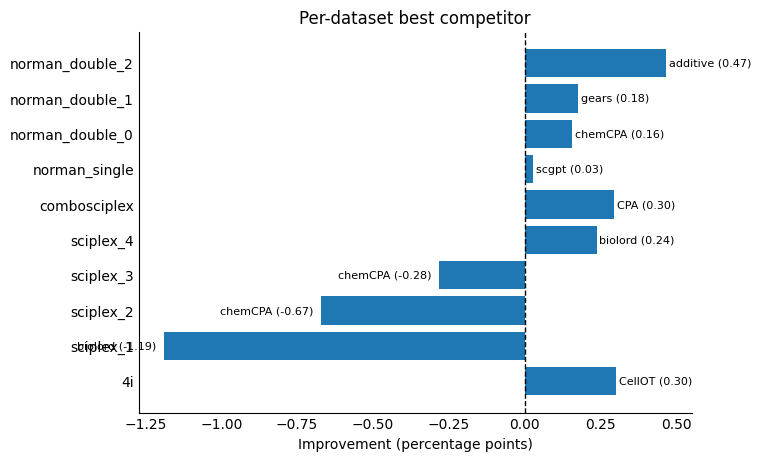

In [194]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

def plot_best_competitors(data: dict,
                          xlabel="Improvement",
                          title="Best competitor per dataset",
                          is_percent=False,
                          figsize=(7, 4),
                          save_path=None):
    """
    Make a horizontal bar chart of per-dataset best competitor & improvement.

    Parameters
    ----------
    data : dict
        {dataset_name: (best_method, improvement_value)}. Order is preserved.
    xlabel : str
        X-axis label
    title : str
        Plot title
    is_percent : bool
        If True, format x-axis as %
    figsize : tuple
        Figure size
    save_path : str or None
        Path to save as PDF/PNG if given
    """
    # Convert dict to DataFrame, preserve order
    df = pd.DataFrame(
        [(ds, m[0], float(m[1])) for ds, m in data.items()],
        columns=["dataset", "method", "improvement"]
    )

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    y_pos = range(len(df))
    ax.barh(y_pos, df["improvement"], color="tab:blue")

    # zero reference line
    ax.axvline(0, color="black", linestyle="--", linewidth=1)

    # y-axis
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df["dataset"])

    # x-axis formatting
    if is_percent:
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
    ax.set_xlabel(xlabel)
    ax.set_title(title)

    # annotate bars with method + value
    max_val = df["improvement"].max()
    min_val = df["improvement"].min()
    for i, (val, method) in enumerate(zip(df["improvement"], df["method"])):
        if val >= 0:
            ax.text(val + 0.02 * max_val,
                    i, f"{method} ({val:.2f})",
                    va="center", ha="left", fontsize=8)
        else:
            ax.text(val - 0.02 * abs(min_val),
                    i, f"{method} ({val:.2f})",
                    va="center", ha="right", fontsize=8)

    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.tick_params(axis="both", which="both", length=0)

    if save_path:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()


# --- Example usage (keeps the order you define here) ---
data = results_dict

plot_best_competitors(
    data,
    xlabel="Improvement (percentage points)",
    title="Per-dataset best competitor",
    is_percent=False,
    figsize=(7.5, 4.5),
    save_path="best_competitor_plot.pdf"
)


# with updated Norman

In [195]:
df = pd.read_csv("/home/icb/dominik.klein/tmp/norman_new.csv")
df = df[df["model"]!="cellflow"]
df["model"] = df.apply(lambda x: "cellflow" if x["model"] == "cellflow_new" else x["model"], axis=1)

In [196]:
df1 = df[df["subgroup"]=="single"]

In [197]:
mean_performance1 = pd.DataFrame(df1.groupby("model")["encoded_ood_e_distance"].median())
mean_performance1["method"] = mean_performance1.index
mean_performance1

,encoded_ood_e_distance,method
model,,
biolord,11.446430,biolord
cellflow,9.060989,cellflow
gears,11.063463,gears
identity,15.443059,identity
scgpt,10.418403,scgpt


In [198]:
cf_performance1 = mean_performance1.loc[["cellflow"]]
best_competitor1 = mean_performance1[mean_performance1["method"]!="cellflow"].sort_values("encoded_ood_e_distance").iloc[[0]]
best_competitor1

,encoded_ood_e_distance,method
model,,
scgpt,10.418403,scgpt


In [199]:
improvement = (best_competitor1["encoded_ood_e_distance"].values - cf_performance1["encoded_ood_e_distance"].values)/best_competitor1["encoded_ood_e_distance"].values
improvement

array([0.13029002])

In [200]:
results_dict["norman_single"] = (best_competitor1.index[0], improvement)

In [201]:
df2 = df[df["subgroup"]=="double_seen_0"]
mean_performance2 = pd.DataFrame(df2.groupby("model")["encoded_ood_e_distance"].median())
mean_performance2["method"] = mean_performance2.index
mean_performance2

,encoded_ood_e_distance,method
model,,
biolord,26.114216,biolord
cellflow,18.804817,cellflow
gears,20.367313,gears
identity,55.628238,identity
scgpt,26.930011,scgpt


In [202]:
cf_performance2 = mean_performance2.loc[["cellflow"]]
best_competitor2 = mean_performance2[mean_performance1["method"]!="cellflow"].sort_values("encoded_ood_e_distance").iloc[[0]]
best_competitor2

,encoded_ood_e_distance,method
model,,
gears,20.367313,gears


In [203]:
improvement = (best_competitor2["encoded_ood_e_distance"].values - cf_performance2["encoded_ood_e_distance"].values)/best_competitor2["encoded_ood_e_distance"].values
improvement

array([0.07671587])

In [204]:
results_dict["norman_double_0"] = (best_competitor3.index[0], improvement)

In [205]:
df3 = df[df["subgroup"]=="double_seen_1"]
mean_performance3 = pd.DataFrame(df3.groupby("model")["encoded_ood_e_distance"].median())
mean_performance3["method"] = mean_performance3.index
mean_performance3

,encoded_ood_e_distance,method
model,,
biolord,15.663891,biolord
cellflow,11.617249,cellflow
gears,14.739131,gears
identity,44.350379,identity
scgpt,18.224606,scgpt


In [206]:
cf_performance3 = mean_performance3.loc[["cellflow"]]
best_competitor3 = mean_performance3[mean_performance3["method"]!="cellflow"].sort_values("encoded_ood_e_distance").iloc[[0]]
best_competitor3

,encoded_ood_e_distance,method
model,,
gears,14.739131,gears


In [207]:
improvement = (best_competitor3["encoded_ood_e_distance"].values - cf_performance3["encoded_ood_e_distance"].values)/best_competitor3["encoded_ood_e_distance"].values
improvement

array([0.21180908])

In [208]:
results_dict["norman_double_1"] = (best_competitor3.index[0], improvement)

In [209]:
df4 = df[df["subgroup"]=="double_seen_2"]
mean_performance4 = pd.DataFrame(df4.groupby("model")["encoded_ood_e_distance"].median())
mean_performance4["method"] = mean_performance4.index
mean_performance4

,encoded_ood_e_distance,method
model,,
additive,5.646977,additive
biolord,5.687315,biolord
cellflow,2.636711,cellflow
gears,7.766070,gears
identity,51.229344,identity
scgpt,12.490374,scgpt


In [210]:
cf_performance4 = mean_performance4.loc[["cellflow"]]
best_competitor4 = mean_performance4[mean_performance4["method"]!="cellflow"].sort_values("encoded_ood_e_distance").iloc[[0]]
best_competitor4

,encoded_ood_e_distance,method
model,,
additive,5.646977,additive


In [211]:
improvement = (best_competitor4["encoded_ood_e_distance"].values - cf_performance4["encoded_ood_e_distance"].values)/best_competitor4["encoded_ood_e_distance"].values
improvement

array([0.53307564])

In [212]:
results_dict["norman_double_2"] = (best_competitor4.index[0], improvement)

/tmp/ipykernel_745383/1608093941.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  [(ds, m[0], float(m[1])) for ds, m in data.items()],


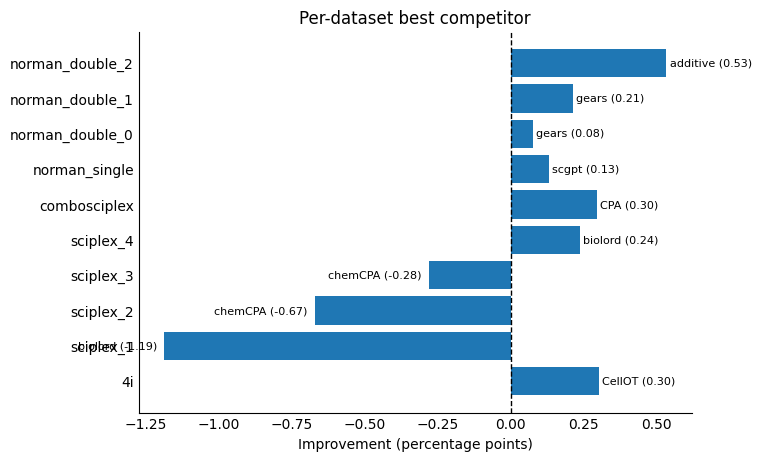

In [213]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

def plot_best_competitors(data: dict,
                          xlabel="Improvement",
                          title="Best competitor per dataset",
                          is_percent=False,
                          figsize=(7, 4),
                          save_path=None):
    """
    Make a horizontal bar chart of per-dataset best competitor & improvement.

    Parameters
    ----------
    data : dict
        {dataset_name: (best_method, improvement_value)}. Order is preserved.
    xlabel : str
        X-axis label
    title : str
        Plot title
    is_percent : bool
        If True, format x-axis as %
    figsize : tuple
        Figure size
    save_path : str or None
        Path to save as PDF/PNG if given
    """
    # Convert dict to DataFrame, preserve order
    df = pd.DataFrame(
        [(ds, m[0], float(m[1])) for ds, m in data.items()],
        columns=["dataset", "method", "improvement"]
    )

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    y_pos = range(len(df))
    ax.barh(y_pos, df["improvement"], color="tab:blue")

    # zero reference line
    ax.axvline(0, color="black", linestyle="--", linewidth=1)

    # y-axis
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df["dataset"])

    # x-axis formatting
    if is_percent:
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
    ax.set_xlabel(xlabel)
    ax.set_title(title)

    # annotate bars with method + value
    max_val = df["improvement"].max()
    min_val = df["improvement"].min()
    for i, (val, method) in enumerate(zip(df["improvement"], df["method"])):
        if val >= 0:
            ax.text(val + 0.02 * max_val,
                    i, f"{method} ({val:.2f})",
                    va="center", ha="left", fontsize=8)
        else:
            ax.text(val - 0.02 * abs(min_val),
                    i, f"{method} ({val:.2f})",
                    va="center", ha="right", fontsize=8)

    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.tick_params(axis="both", which="both", length=0)

    if save_path:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()


# --- Example usage (keeps the order you define here) ---
data = results_dict

plot_best_competitors(
    data,
    xlabel="Improvement (percentage points)",
    title="Per-dataset best competitor",
    is_percent=False,
    figsize=(7.5, 4.5),
    save_path="best_competitor_plot.pdf"
)
